In [27]:
# Cell 1 — Imports, settings, and loading data + base model

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler

import joblib
import json
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported.")

# Paths
processed_path = "../data/processed"
models_path    = "../models"

# Load datasets (with lifestyle + cluster + demographics + Stress_Level)
train_df = pd.read_csv(os.path.join(processed_path, "train_with_clusters.csv"))
val_df   = pd.read_csv(os.path.join(processed_path, "val_with_clusters.csv"))
test_df  = pd.read_csv(os.path.join(processed_path, "test_with_clusters.csv"))

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

# Load base model: Lifestyle + Cluster (Model B from Notebook 04)
base_model_path = os.path.join(models_path, "multinomial_logreg_lifestyle_cluster.pkl")
model_base = joblib.load(base_model_path)

# Load feature config from Notebook 04
config_path = os.path.join(models_path, "model_config.json")
with open(config_path, "r") as f:
    config = json.load(f)

features_base = config["features_model_B"]   # lifestyle + cluster
target_col    = config["target"]
class_labels  = config["classes"]

print("\nBase model and config loaded.")
print("Base model features:", features_base)
print("Target column:", target_col)
print("Class labels:", class_labels)


Libraries imported.
Train shape: (7866, 27)
Val shape:   (2245, 27)
Test shape:  (1124, 27)

Base model and config loaded.
Base model features: ['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled', 'Cluster']
Target column: Stress_Level
Class labels: ['High', 'Low', 'Medium']


In [28]:
# Cell 2 — Define column groups (lifestyle, cluster, demographics)

# Lifestyle features: same logic as before (scaled habits only)
lifestyle_features = [
    col for col in train_df.columns
    if col.endswith("_Scaled") and not col.startswith("Age")
]

cluster_feature = ["Cluster"]

print("Lifestyle features:", lifestyle_features)
print("Cluster feature:", cluster_feature)

# Demographic raw columns: Age / Age_Scaled, Gender, Occupation, Country
demo_raw = []

if "Age_Scaled" in train_df.columns:
    age_col = "Age_Scaled"
    demo_raw.append(age_col)
elif "Age" in train_df.columns:
    age_col = "Age"
    demo_raw.append(age_col)
else:
    age_col = None
    print("WARNING: No Age or Age_Scaled column found.")

for col in ["Gender", "Occupation", "Country"]:
    if col in train_df.columns:
        demo_raw.append(col)

print("Demographic raw columns:", demo_raw)
print("Unique Stress Levels in training set:", train_df[target_col].unique())


Lifestyle features: ['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled']
Cluster feature: ['Cluster']
Demographic raw columns: ['Age', 'Gender', 'Occupation', 'Country']
Unique Stress Levels in training set: ['High' 'Medium' 'Low']


In [29]:
# Cell 3 — Preprocess demographic variables:
# - Scale Age 
# - One-hot encode Gender, Occupation, Country
# - Align val/test dummy columns with train

train_demo = train_df[demo_raw].copy()
val_demo   = val_df[demo_raw].copy()
test_demo  = test_df[demo_raw].copy()

# 1) Handle Age scaling
if age_col == "Age":
    scaler_age = MinMaxScaler()
    train_demo["Age_Scaled"] = scaler_age.fit_transform(train_demo[["Age"]])
    val_demo["Age_Scaled"]   = scaler_age.transform(val_demo[["Age"]])
    test_demo["Age_Scaled"]  = scaler_age.transform(test_demo[["Age"]])
elif age_col == "Age_Scaled":
    # already scaled; nothing to do
    pass

# From this point, we will use Age_Scaled (if available)
if "Age_Scaled" in train_demo.columns:
    age_feature = "Age_Scaled"
else:
    age_feature = None
    print("No Age_Scaled available after preprocessing.")

# 2) One-hot encode Gender, Occupation, Country
cat_cols = [c for c in ["Gender", "Occupation", "Country"] if c in train_demo.columns]

train_cats = pd.get_dummies(train_demo[cat_cols], drop_first=False)
val_cats   = pd.get_dummies(val_demo[cat_cols], drop_first=False)
test_cats  = pd.get_dummies(test_demo[cat_cols], drop_first=False)

# Align val/test categorical columns with train (fill missing with 0)
val_cats  = val_cats.reindex(columns=train_cats.columns, fill_value=0)
test_cats = test_cats.reindex(columns=train_cats.columns, fill_value=0)

# 3) Combine Age_Scaled (if present) + categorical dummies into processed demographic matrices
if age_feature is not None:
    demo_train_processed = pd.concat([train_demo[[age_feature]], train_cats], axis=1)
    demo_val_processed   = pd.concat([val_demo[[age_feature]],   val_cats],   axis=1)
    demo_test_processed  = pd.concat([test_demo[[age_feature]],  test_cats],  axis=1)
else:
    demo_train_processed = train_cats.copy()
    demo_val_processed   = val_cats.copy()
    demo_test_processed  = test_cats.copy()

print("Processed demographic feature shapes:")
print("  Train demo:", demo_train_processed.shape)
print("  Val demo:  ", demo_val_processed.shape)
print("  Test demo: ", demo_test_processed.shape)

demo_train_processed.head()


Processed demographic feature shapes:
  Train demo: (7866, 19)
  Val demo:   (2245, 19)
  Test demo:  (1124, 19)


,Age_Scaled,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Prefer not to say,Occupation_Education,Occupation_Engineering,Occupation_Finance,Occupation_Healthcare,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
0,0.872340,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False
1,0.893617,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,0.659574,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
3,0.404255,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,0.361702,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False


In [30]:
# Cell 4 — Build X and y for base (loaded) and demo (new) models

# Target (same for both models)
y_train = train_df[target_col]
y_val   = val_df[target_col]
y_test  = test_df[target_col]

# Base model features — EXACTLY as used in Notebook 04
X_train_base = train_df[features_base]
X_val_base   = val_df[features_base]
X_test_base  = test_df[features_base]

print("Base model feature shape (train):", X_train_base.shape)

# Demo model features: base features + demographics
X_train_demo = pd.concat([X_train_base.reset_index(drop=True),
                          demo_train_processed.reset_index(drop=True)], axis=1)
X_val_demo   = pd.concat([X_val_base.reset_index(drop=True),
                          demo_val_processed.reset_index(drop=True)],   axis=1)
X_test_demo  = pd.concat([X_test_base.reset_index(drop=True),
                          demo_test_processed.reset_index(drop=True)],  axis=1)

print("Demographic model feature shape (train):", X_train_demo.shape)
X_train_demo.head()


Base model feature shape (train): (7866, 8)
Demographic model feature shape (train): (7866, 27)


,Sleep_Hours_Scaled,Work_Hours_Scaled,Physical_Activity_Hours_Scaled,Social_Media_Usage_Scaled,Diet_Quality_Encoded_Scaled,Smoking_Habit_Encoded_Scaled,Alcohol_Consumption_Encoded_Scaled,Cluster,Age_Scaled,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Prefer not to say,Occupation_Education,Occupation_Engineering,Occupation_Finance,Occupation_Healthcare,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
0,0.566667,0.94,0.3,0.200000,0.5,1.000000,0.666667,1,0.872340,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False
1,0.450000,0.70,0.7,0.618182,1.0,0.333333,0.000000,1,0.893617,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,0.666667,0.66,0.3,0.872727,0.0,1.000000,0.333333,0,0.659574,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
3,0.916667,0.18,0.4,0.054545,0.0,0.333333,1.000000,0,0.404255,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,0.850000,0.96,0.9,0.345455,1.0,1.000000,1.000000,1,0.361702,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False


In [31]:
# Cell 5 — Evaluate the already-trained BASE model (lifestyle + cluster)

# Validation performance
val_pred_base = model_base.predict(X_val_base)
val_acc_base  = accuracy_score(y_val, val_pred_base)

print("===== BASE MODEL (Lifestyle + Cluster) — VALIDATION =====")
print("Validation Accuracy:", round(val_acc_base, 4))
print(classification_report(y_val, val_pred_base, digits=3))

# Test performance
test_pred_base = model_base.predict(X_test_base)
test_acc_base  = accuracy_score(y_test, test_pred_base)

print("\n===== BASE MODEL (Lifestyle + Cluster) — TEST =====")
print("Test Accuracy:", round(test_acc_base, 4))
print(classification_report(y_test, test_pred_base, digits=3))


===== BASE MODEL (Lifestyle + Cluster) — VALIDATION =====
Validation Accuracy: 0.9354
              precision    recall  f1-score   support

        High      0.955     0.956     0.956      1077
         Low      0.972     0.942     0.957       591
      Medium      0.864     0.889     0.876       577

    accuracy                          0.935      2245
   macro avg      0.930     0.929     0.930      2245
weighted avg      0.936     0.935     0.936      2245


===== BASE MODEL (Lifestyle + Cluster) — TEST =====
Test Accuracy: 0.9324
              precision    recall  f1-score   support

        High      0.953     0.946     0.950       539
         Low      0.979     0.946     0.962       296
      Medium      0.851     0.893     0.872       289

    accuracy                          0.932      1124
   macro avg      0.928     0.928     0.928      1124
weighted avg      0.934     0.932     0.933      1124



In [32]:
# Cell 6 — Train DEMOGRAPHIC model (Lifestyle + Cluster + Demographics)

model_demo = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model_demo.fit(X_train_demo, y_train)

print("Demographic model trained (lifestyle + cluster + demographics).")


Demographic model trained (lifestyle + cluster + demographics).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [33]:
# Cell 7 — Validation performance comparison: Base vs Demo model

val_pred_demo = model_demo.predict(X_val_demo)
val_acc_demo  = accuracy_score(y_val, val_pred_demo)

print("===== VALIDATION ACCURACY COMPARISON =====")
print(f"Base model (Lifestyle + Cluster):                {val_acc_base:.4f}")
print(f"Demographic model (Lifestyle + Cluster + Demo):  {val_acc_demo:.4f}")

print("\n--- Base model (Validation) ---")
print(classification_report(y_val, val_pred_base, digits=3))

print("\n--- Demo model (Validation) ---")
print(classification_report(y_val, val_pred_demo, digits=3))


===== VALIDATION ACCURACY COMPARISON =====
Base model (Lifestyle + Cluster):                0.9354
Demographic model (Lifestyle + Cluster + Demo):  0.9323

--- Base model (Validation) ---
              precision    recall  f1-score   support

        High      0.955     0.956     0.956      1077
         Low      0.972     0.942     0.957       591
      Medium      0.864     0.889     0.876       577

    accuracy                          0.935      2245
   macro avg      0.930     0.929     0.930      2245
weighted avg      0.936     0.935     0.936      2245


--- Demo model (Validation) ---
              precision    recall  f1-score   support

        High      0.953     0.955     0.954      1077
         Low      0.970     0.939     0.954       591
      Medium      0.858     0.882     0.870       577

    accuracy                          0.932      2245
   macro avg      0.927     0.926     0.926      2245
weighted avg      0.933     0.932     0.933      2245



In [34]:
# Cell 8 — Test performance comparison: Base vs Demo model

test_pred_demo = model_demo.predict(X_test_demo)
test_acc_demo  = accuracy_score(y_test, test_pred_demo)

print("===== TEST ACCURACY COMPARISON =====")
print(f"Base model (Lifestyle + Cluster):                {test_acc_base:.4f}")
print(f"Demographic model (Lifestyle + Cluster + Demo):  {test_acc_demo:.4f}")

print("\n--- Base model (Test) ---")
print(classification_report(y_test, test_pred_base, digits=3))

print("\n--- Demo model (Test) ---")
print(classification_report(y_test, test_pred_demo, digits=3))


===== TEST ACCURACY COMPARISON =====
Base model (Lifestyle + Cluster):                0.9324
Demographic model (Lifestyle + Cluster + Demo):  0.9342

--- Base model (Test) ---


              precision    recall  f1-score   support

        High      0.953     0.946     0.950       539
         Low      0.979     0.946     0.962       296
      Medium      0.851     0.893     0.872       289

    accuracy                          0.932      1124
   macro avg      0.928     0.928     0.928      1124
weighted avg      0.934     0.932     0.933      1124


--- Demo model (Test) ---
              precision    recall  f1-score   support

        High      0.955     0.946     0.951       539
         Low      0.976     0.953     0.964       296
      Medium      0.857     0.893     0.875       289

    accuracy                          0.934      1124
   macro avg      0.929     0.931     0.930      1124
weighted avg      0.935     0.934     0.935      1124



In [35]:
# Cell 9 — Inspect coefficients of demographic features in the Demo model

demo_feature_names = list(demo_train_processed.columns)

# Get full coefficient matrix: rows = classes, cols = all features in X_train_demo
coef_df = pd.DataFrame(
    model_demo.coef_,
    columns=X_train_demo.columns,
    index=model_demo.classes_
)

demo_coefs_only = coef_df[demo_feature_names]

print("===== Demographic Coefficients per Class =====")
display(demo_coefs_only.round(4))


===== Demographic Coefficients per Class =====


,Age_Scaled,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Prefer not to say,Occupation_Education,Occupation_Engineering,Occupation_Finance,Occupation_Healthcare,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
High,-0.2245,-0.0471,0.1022,0.0057,-0.0729,0.0109,-0.0448,-0.0676,0.0199,-0.0232,0.1209,-0.0282,-0.1732,0.0940,0.0227,0.0733,-0.0408,0.0356,-0.0238
Low,0.1218,-0.0172,-0.0486,0.0526,0.0307,-0.0045,-0.0177,0.0116,0.0384,0.0309,-0.1226,0.0815,0.1715,-0.0589,-0.0657,-0.0787,0.0608,0.0208,-0.0324
Medium,0.1026,0.0643,-0.0536,-0.0583,0.0422,-0.0064,0.0625,0.0560,-0.0583,-0.0076,0.0017,-0.0533,0.0017,-0.0351,0.0430,0.0054,-0.0201,-0.0564,0.0561


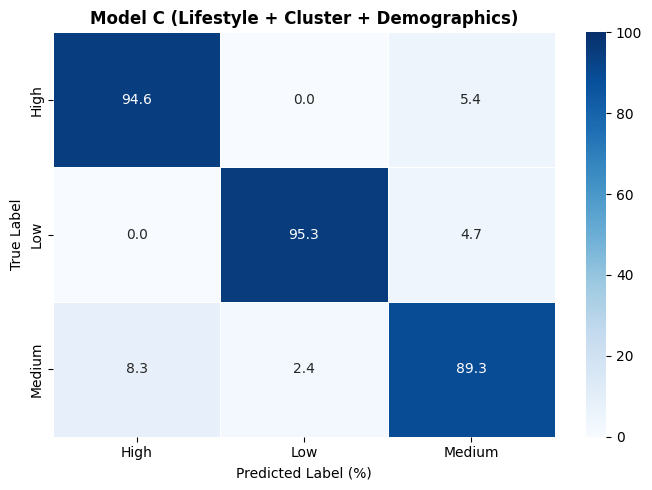

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

classes = ['High', 'Low', 'Medium']

test_pred_demo = model_demo.predict(X_test_demo)

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, test_pred_demo, labels=classes)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
    linewidths=0.5,
    vmin=0,
    vmax=100
)
ax.set_title('Model C (Lifestyle + Cluster + Demographics)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label (%)', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix_C.png', dpi=150, bbox_inches='tight')
plt.show()

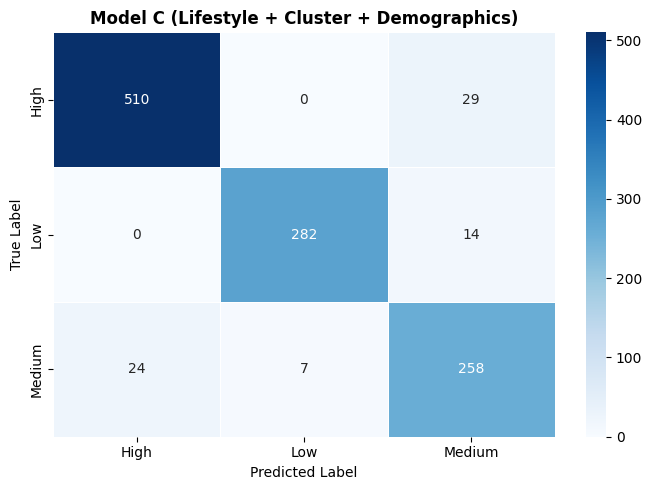

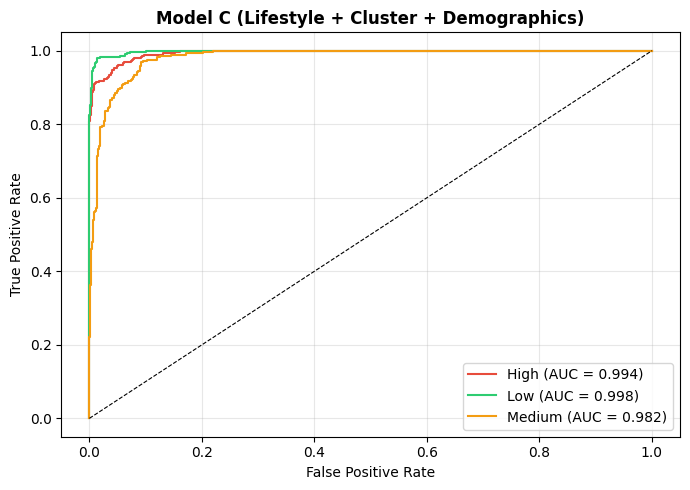

Model C Macro AUC-ROC: 0.9911


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np

classes = ['High', 'Low', 'Medium']
y_test_bin = label_binarize(y_test, classes=classes)

# Get predictions and probabilities for Model C only
test_pred_demo = model_demo.predict(X_test_demo)
test_prob_demo = model_demo.predict_proba(X_test_demo)

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, test_pred_demo, labels=classes)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Model C (Lifestyle + Cluster + Demographics)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix_C.png', dpi=150, bbox_inches='tight')
plt.show()

# --- AUC-ROC ---
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#E74C3C', '#2ECC71', '#F39C12']
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_prob_demo[:, i])
    auc = roc_auc_score(y_test_bin[:, i], test_prob_demo[:, i])
    ax.plot(fpr, tpr, color=color,
            label=f'{cls} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('Model C (Lifestyle + Cluster + Demographics)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('auc_roc_C.png', dpi=150, bbox_inches='tight')
plt.show()

# Print AUC score
print("Model C Macro AUC-ROC:",
      round(roc_auc_score(y_test_bin, test_prob_demo, average='macro'), 4))

In [41]:
import joblib
joblib.dump(model_demo, "../models/model_C_lifestyle_cluster_demo.pkl")
print("Model C saved!")

Model C saved!
